In [2]:
import pandas as pd
from scipy.stats import chi2_contingency

# ── Load data ──────────────────────────────────────────────────────────────────
merged = pd.read_csv("btc_fng_with_holidays_api.csv", parse_dates=["date"])
merged["btc_return_pct"] = pd.to_numeric(merged["btc_return_pct"], errors="coerce")
merged = merged.dropna(subset=["btc_return_pct"])

# ── Create gain flag ───────────────────────────────────────────────────────────
merged["gain"] = merged["btc_return_pct"] > 0

# ── Contingency table ──────────────────────────────────────────────────────────
contingency_table = pd.crosstab(merged["gain"], merged["is_holiday"])
print("Contingency Table:")
print(contingency_table)

# ── Chi-Square test ────────────────────────────────────────────────────────────
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("\nChi-Square Test Results:")
print(f"Chi2 statistic: {chi2:.4f}")
print(f"p-value:        {p:.4f}")
print(f"Degrees of freedom: {dof}")
print("\nExpected frequencies:")
print(pd.DataFrame(expected,
                   index=contingency_table.index,
                   columns=contingency_table.columns).round(2))

Contingency Table:
is_holiday  False  True 
gain                    
False         172     10
True          173      9

Chi-Square Test Results:
Chi2 statistic: 0.0000
p-value:        1.0000
Degrees of freedom: 1

Expected frequencies:
is_holiday  False  True 
gain                    
False       172.5    9.5
True        172.5    9.5


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def chart_gain_vs_holiday(merged):
    """
    Creates a bar chart showing % of BTC gain days on holidays vs non-holidays.
    """
    # Ensure 'gain' is boolean
    merged["gain"] = merged["btc_return_pct"] > 0

    # Compute % gain per category
    pct_gain = merged.groupby("is_holiday")["gain"].mean() * 100
    pct_gain = pct_gain.rename({True: "Holiday", False: "Not Holiday"})

    # Plot
    sns.set_style("whitegrid")
    plt.figure(figsize=(6,4))
    ax = sns.barplot(x=pct_gain.index, y=pct_gain.values, palette="coolwarm")
    plt.title("% of BTC Gain Days: Holiday vs Not Holiday", fontsize=14)
    plt.ylabel("Percent of Days with BTC Gain")
    plt.ylim(0, 100)

    # Add values on top of bars
    for i, v in enumerate(pct_gain.values):
        ax.text(i, v + 1, f"{v:.1f}%", ha='center', fontsize=10)

    plt.tight_layout()
    plt.show()

C:\Users\Christopher\AppData\Local\Temp\ipykernel_25328\3518201180.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=pct_gain.index, y=pct_gain.values, palette="coolwarm")


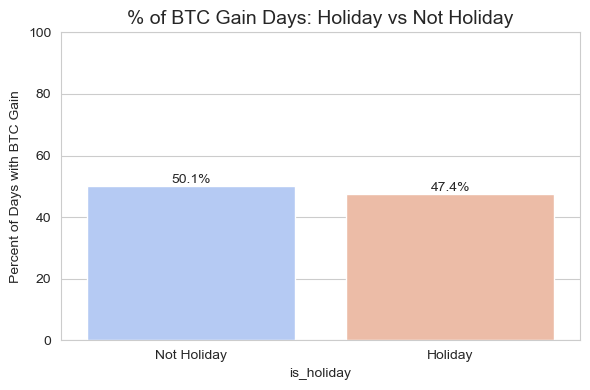

In [4]:
chart_gain_vs_holiday(merged)

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

def distribution_chart_gain_vs_holiday(merged):
    """
    Plots the distribution of BTC daily returns for Holiday vs Not Holiday.
    """
    sns.set_style("whitegrid")
    
    # Ensure 'gain' is boolean
    merged["gain"] = merged["btc_return_pct"] > 0
    
    plt.figure(figsize=(10,6))
    sns.kdeplot(
        data=merged, 
        x="btc_return_pct", 
        hue="is_holiday", 
        fill=True,
        common_norm=False,
        palette={True: "red", False: "blue"},
        alpha=0.4
    )
    plt.title("Distribution of BTC Daily Returns: Holiday vs Not Holiday", fontsize=14)
    plt.xlabel("BTC Daily Return (%)")
    plt.ylabel("Density")
    plt.legend(title="Holiday", labels=["Not Holiday", "Holiday"])
    plt.axvline(0, color="black", linestyle="--", linewidth=1)  # Reference line at 0%
    plt.tight_layout()
    plt.show()

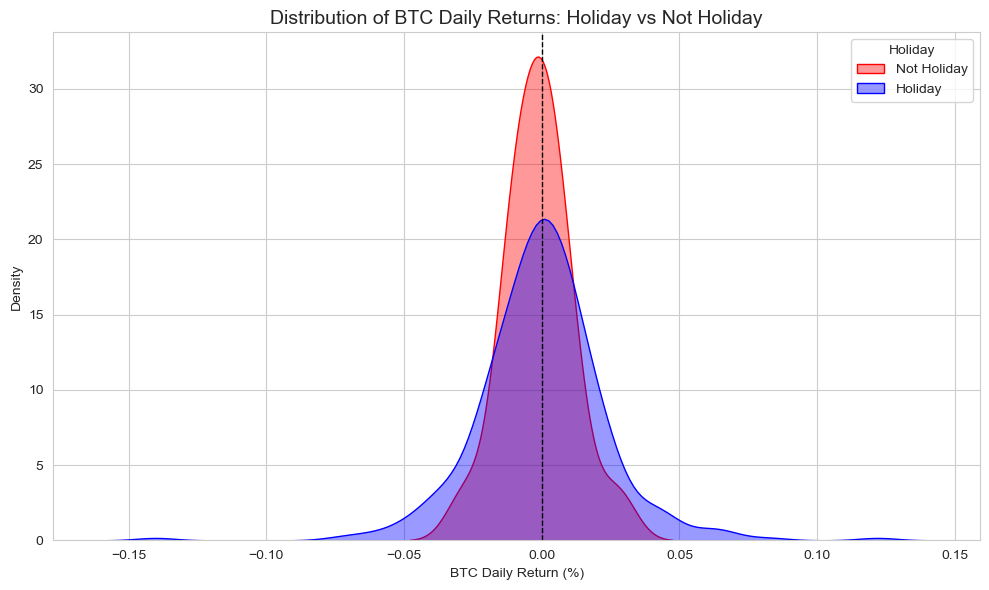

In [6]:
distribution_chart_gain_vs_holiday(merged)

C:\Users\Christopher\AppData\Local\Temp\ipykernel_25328\2141487748.py:170: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  plt.savefig("btc_chisquare_kde.png", dpi=150, bbox_inches="tight", facecolor="#f8f8f6")


Saved: btc_chisquare_kde.png

=== Contingency Table ===
is_holiday  False  True 
gain                    
False         172     10
True          173      9

=== Chi-Square Test ===
χ²  = 0.0000
p   = 1.0000
dof = 1

Expected frequencies:
      Not Holiday  Holiday
Loss        172.5      9.5
Gain        172.5      9.5

Result: Gain/loss is NOT significantly associated with holiday status.


c:\Users\Christopher\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


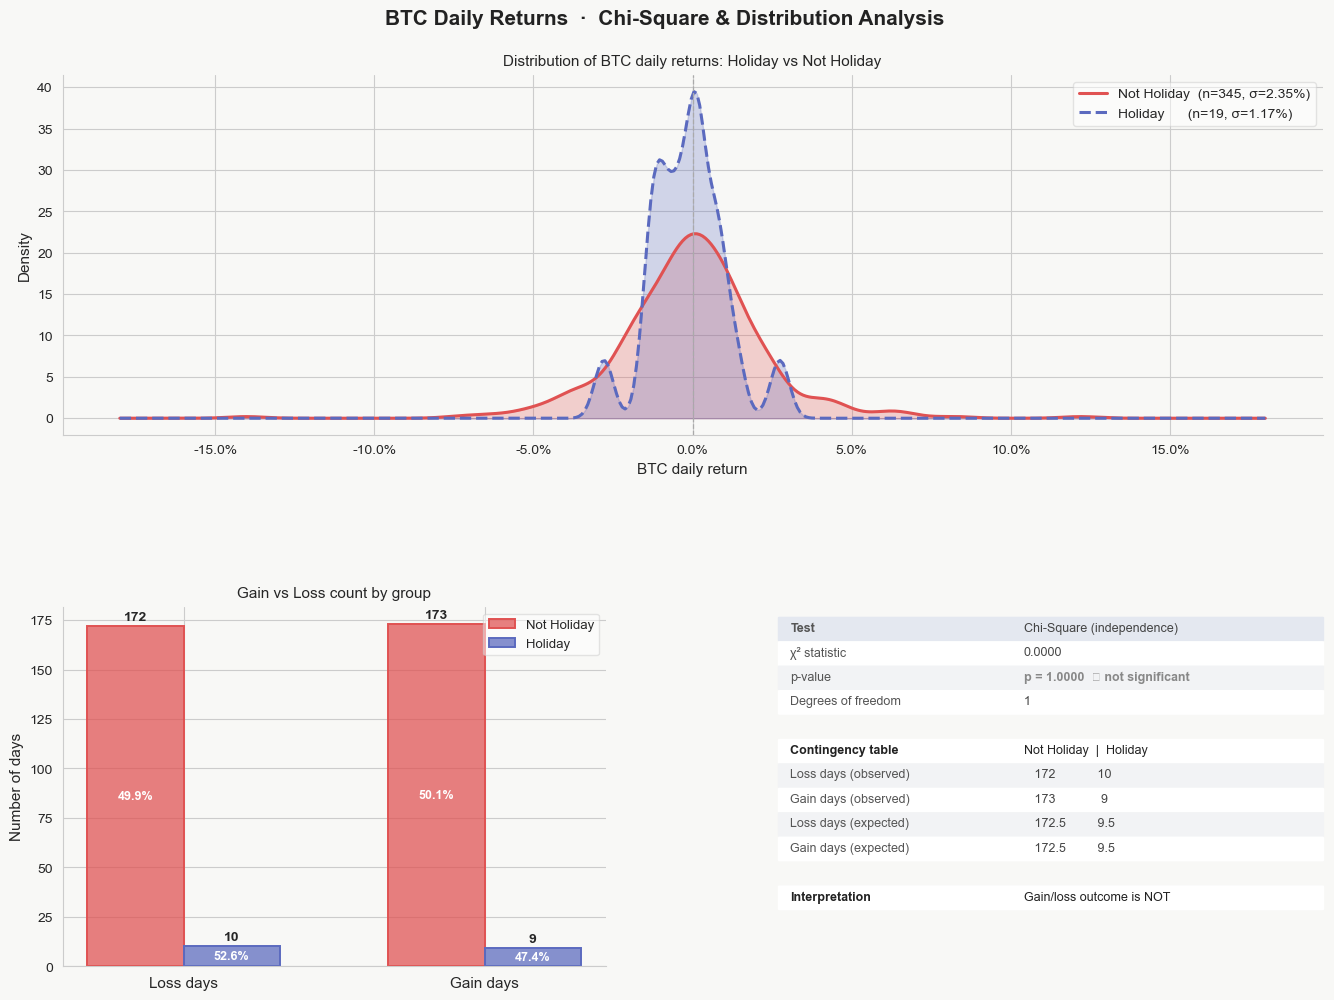

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
from scipy.stats import chi2_contingency
from scipy.stats import gaussian_kde

# ── Load data ──────────────────────────────────────────────────────────────────
df = pd.read_csv("btc_fng_with_holidays_api.csv", parse_dates=["date"])
df["btc_return_pct"] = pd.to_numeric(df["btc_return_pct"], errors="coerce")
df = df.dropna(subset=["btc_return_pct"]).drop_duplicates(subset="date").sort_values("date").reset_index(drop=True)

# ── Feature engineering ────────────────────────────────────────────────────────
df["gain"] = df["btc_return_pct"] > 0

holiday     = df[df["is_holiday"]]["btc_return_pct"].values
not_holiday = df[~df["is_holiday"]]["btc_return_pct"].values

# ── Chi-square test ────────────────────────────────────────────────────────────
contingency_table = pd.crosstab(df["gain"], df["is_holiday"])
chi2_stat, p_val, dof, expected = chi2_contingency(contingency_table)

# Pull counts for bar chart
ct = contingency_table.copy()
ct.columns = ["Not Holiday", "Holiday"]
ct.index   = ["Loss", "Gain"]

# ── KDE helper ─────────────────────────────────────────────────────────────────
def smooth_kde(data, xs):
    kde = gaussian_kde(data, bw_method=0.25)
    return kde(xs)

xs = np.linspace(-0.18, 0.18, 400)

# ── Figure ─────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 11), facecolor="#f8f8f6")
gs  = gridspec.GridSpec(2, 2, figure=fig,
                        hspace=0.48, wspace=0.32,
                        left=0.07, right=0.97,
                        top=0.88, bottom=0.07)

ax_kde  = fig.add_subplot(gs[0, :])    # full-width KDE
ax_bar  = fig.add_subplot(gs[1, 0])    # gain/loss bar chart
ax_tbl  = fig.add_subplot(gs[1, 1])    # results table

fig.suptitle("BTC Daily Returns  ·  Chi-Square & Distribution Analysis",
             fontsize=15, fontweight="bold", color="#222", y=0.94)

COL_NH = "#e05252"   # not-holiday red
COL_H  = "#5b6abf"   # holiday blue

# ── 1. KDE plot ────────────────────────────────────────────────────────────────
ax_kde.set_facecolor("#f8f8f6")

ys_nh = smooth_kde(not_holiday, xs)
ys_h  = smooth_kde(holiday, xs)

ax_kde.fill_between(xs, ys_nh, alpha=0.25, color=COL_NH)
ax_kde.fill_between(xs, ys_h,  alpha=0.25, color=COL_H)
ax_kde.plot(xs, ys_nh, color=COL_NH, lw=2.2,
            label=f"Not Holiday  (n={len(not_holiday)}, σ={not_holiday.std()*100:.2f}%)")
ax_kde.plot(xs, ys_h,  color=COL_H,  lw=2.2, ls="--",
            label=f"Holiday      (n={len(holiday)}, σ={holiday.std()*100:.2f}%)")

ax_kde.axvline(0, color="#aaa", lw=0.9, ls="--")
ax_kde.set_xlabel("BTC daily return", fontsize=11)
ax_kde.set_ylabel("Density", fontsize=11)
ax_kde.set_title("Distribution of BTC daily returns: Holiday vs Not Holiday", fontsize=11, pad=7)
ax_kde.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x*100:.1f}%"))
ax_kde.legend(fontsize=10, framealpha=0.5, loc="upper right")
ax_kde.spines[["top", "right"]].set_visible(False)

# ── 2. Gain / Loss grouped bar chart ──────────────────────────────────────────
ax_bar.set_facecolor("#f8f8f6")

x      = np.array([0, 1])
width  = 0.32
nh_vals = [ct.loc["Loss","Not Holiday"], ct.loc["Gain","Not Holiday"]]
h_vals  = [ct.loc["Loss","Holiday"],     ct.loc["Gain","Holiday"]]

bars_nh = ax_bar.bar(x - width/2, nh_vals, width, label="Not Holiday",
                     color=COL_NH + "bb", edgecolor=COL_NH, linewidth=1.4)
bars_h  = ax_bar.bar(x + width/2, h_vals,  width, label="Holiday",
                     color=COL_H  + "bb", edgecolor=COL_H,  linewidth=1.4)

for bar in list(bars_nh) + list(bars_h):
    ax_bar.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 1.5,
                str(int(bar.get_height())),
                ha="center", va="bottom", fontsize=10, fontweight="bold")

# Add observed % labels inside bars
total_nh = len(not_holiday)
total_h  = len(holiday)
pcts = [
    nh_vals[0]/total_nh, nh_vals[1]/total_nh,
    h_vals[0]/total_h,   h_vals[1]/total_h
]
for bar, pct in zip(list(bars_nh) + list(bars_h), pcts[:2] + pcts[2:]):
    ax_bar.text(bar.get_x() + bar.get_width()/2,
                bar.get_height()/2,
                f"{pct*100:.1f}%",
                ha="center", va="center", fontsize=9,
                color="white", fontweight="bold")

ax_bar.set_xticks(x)
ax_bar.set_xticklabels(["Loss days", "Gain days"], fontsize=11)
ax_bar.set_ylabel("Number of days", fontsize=11)
ax_bar.set_title("Gain vs Loss count by group", fontsize=11, pad=7)
ax_bar.legend(fontsize=9.5, framealpha=0.5)
ax_bar.spines[["top", "right"]].set_visible(False)
ax_bar.set_facecolor("#f8f8f6")

# ── 3. Results table ───────────────────────────────────────────────────────────
ax_tbl.axis("off")
ax_tbl.set_facecolor("#f8f8f6")

sig_label = "p < 0.05  ✓ significant" if p_val < 0.05 else f"p = {p_val:.4f}  ✗ not significant"
sig_color = "#185fa5" if p_val < 0.05 else "#888"

rows = [
    ("Test",                    "Chi-Square (independence)"),
    ("χ² statistic",            f"{chi2_stat:.4f}"),
    ("p-value",                 sig_label),
    ("Degrees of freedom",      str(dof)),
    ("",                        ""),
    ("Contingency table",       "Not Holiday  |  Holiday"),
    ("Loss days (observed)",    f"{ct.loc['Loss','Not Holiday']:>6}          {ct.loc['Loss','Holiday']:>4}"),
    ("Gain days (observed)",    f"{ct.loc['Gain','Not Holiday']:>6}          {ct.loc['Gain','Holiday']:>4}"),
    ("Loss days (expected)",    f"{expected[0][0]:>8.1f}      {expected[0][1]:>6.1f}"),
    ("Gain days (expected)",    f"{expected[1][0]:>8.1f}      {expected[1][1]:>6.1f}"),
    ("",                        ""),
    ("Interpretation",          "Gain/loss outcome is" + (" NOT" if p_val >= 0.05 else "")),
    ("",                        "independent of holiday status"),
]

row_h  = 0.068
start_y = 0.97

for r_idx, (label, value) in enumerate(rows):
    y = start_y - r_idx * row_h
    if label == "":
        continue

    is_header = label == "Test"
    is_sig    = label == "p-value"
    is_section= label in ("Contingency table", "Interpretation")

    bg = "#e4e8f0" if is_header else ("#f2f3f5" if r_idx % 2 == 0 else "#ffffff")
    rect = FancyBboxPatch((0, y - row_h + 0.005), 1.0, row_h - 0.005,
                          boxstyle="round,pad=0.003",
                          facecolor=bg, edgecolor="none",
                          transform=ax_tbl.transAxes, clip_on=False)
    ax_tbl.add_patch(rect)

    lc = "#555" if not is_section else "#222"
    vc = sig_color if is_sig else ("#222" if is_section else "#444")
    lw = "bold" if (is_header or is_section) else "normal"

    ax_tbl.text(0.02, y - row_h * 0.42, label,
                transform=ax_tbl.transAxes,
                fontsize=9, fontweight=lw, color=lc, va="center", ha="left", clip_on=False)
    ax_tbl.text(0.45, y - row_h * 0.42, value,
                transform=ax_tbl.transAxes,
                fontsize=9, fontweight="bold" if is_sig else "normal",
                color=vc, va="center", ha="left", clip_on=False)

# ── Save ───────────────────────────────────────────────────────────────────────
plt.savefig("btc_chisquare_kde.png", dpi=150, bbox_inches="tight", facecolor="#f8f8f6")
print("Saved: btc_chisquare_kde.png")

# ── Console summary ────────────────────────────────────────────────────────────
print("\n=== Contingency Table ===")
print(contingency_table.to_string())
print(f"\n=== Chi-Square Test ===")
print(f"χ²  = {chi2_stat:.4f}")
print(f"p   = {p_val:.4f}")
print(f"dof = {dof}")
print(f"\nExpected frequencies:")
print(pd.DataFrame(expected,
                   index=["Loss","Gain"],
                   columns=["Not Holiday","Holiday"]).round(2).to_string())
print(f"\nResult: Gain/loss is {'NOT ' if p_val >= 0.05 else ''}significantly associated with holiday status.")